In [1]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import pandas as pd
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt
import numpy as np
import unicodedata
import glob, os
from matplotlib import font_manager, rcParams

# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"

In [2]:
def myVenn(df, c1, c2, c3, savepath=None):
    """
    Create a Venn diagram showing overlap of correct predictions between three models.
    
    Parameters:
    - df: DataFrame with prediction columns
    - c1, c2, c3: Column names for the three models to compare
    - savepath: Optional path to save the figure
    """
    # Pastel color palette
    venn_colors = ["#8DA0CB", "#FDBF6F", "#66C2A5"]
    
    # Create unique identifiers for correct predictions
    df[f"{c1}_set"] = df[c1] + df['SAMPLE_ID']
    df[f"{c2}_set"] = df[c2] + df['SAMPLE_ID']
    df[f"{c3}_set"] = df[c3] + df['SAMPLE_ID']

    plt.figure(figsize=(9, 8))
    venn = venn3(
        subsets=([set(df[f"{c1}_set"]), set(df[f"{c2}_set"]), set(df[f"{c3}_set"])]),
        set_labels=(c1.replace("_", " "), c2.replace("_", " "), c3.replace("_", " ")),
        set_colors=venn_colors,
        alpha=0.6
    )

    venn3_circles(
        subsets=([set(df[f"{c1}_set"]), set(df[f"{c2}_set"]), set(df[f"{c3}_set"])]),
        linestyle="solid", linewidth=1.2, color="gray"
    )

    # Add labels with counts and percentages
    total = len(df)
    region_codes = ['001', '010', '100', '011', '110', '101', '111']
    
    for code in region_codes:
        lbl = venn.get_label_by_id(code)
        if lbl and int(lbl.get_text()) > 0:
            pct = f"{int(lbl.get_text())/total:.1%}"
            lbl.set_text(f"{int(lbl.get_text())}\n{pct}")
            lbl.set_fontsize(16)
            lbl.set_color("gray")
            lbl.set_weight("bold")
    
    # Style set labels
    for lbl in venn.set_labels:
        if lbl:
            lbl.set_fontsize(20)
            lbl.set_weight("bold")
            lbl.set_color("black")
    
    if savepath:
        plt.savefig(savepath, dpi=500, bbox_inches='tight')
    plt.show()

def normalize(name):
    """Normalize unicode characters in names."""
    name = unicodedata.normalize('NFKD', name)
    name = name.replace('‑', '-')  # non-breaking hyphen
    name = name.replace('‐', '-')  # hyphen
    name = name.replace('–', '-')  # en dash
    name = name.replace('—', '-')  # em dash
    name = name.replace(',', '')  # remove commas
    return name

## Load mutation status prediction results

In [3]:
"""Load and prepare the mutation status data for Venn diagram analysis."""

# Configuration
BASE_RESULTS_DIR = "/data1/morrisq/yuj13/llm_genomics/mutation_output/mutation_status_with_chr"
SAMPLE_TSVS = [
    '/data1/morrisq/yuj13/llm_genomics/genie_data_v17.0/data_clinical_sample.txt',
    '/data1/morrisq/yuj13/llm_genomics/msk_ch_2023/data_clinical_sample.txt'
]
MODEL_NAMES = ["gpt-5", "o3-mini", "gpt-4o", "medgemma", "qwen3", "claude-sonnet-37", "claude-opus-45", "deepseek", "MetaCH"]

# Helper functions
def build_sampleid_to_cancer(sample_tsvs):
    """Build mapping from SAMPLE_ID to CANCER_TYPE from clinical data."""
    samp2ct = {}
    for tsv_path in sample_tsvs:
        df_temp = pd.read_csv(tsv_path, sep='\t', comment='#')
        for _, row in df_temp.iterrows():
            samp2ct[row['SAMPLE_ID']] = row.get('CANCER_TYPE', 'UNKNOWN')
    return samp2ct

def load_all_model_predictions(model_dirs, model_names, samp2ct, ground_truth_label='ground_truth'):
    """Load predictions from all models and merge into single dataframe."""
    merged = None
    
    for model_dir, model_name in zip(model_dirs, model_names):
        csv_files = glob.glob(os.path.join(model_dir, "*.csv"))
        if not csv_files:
            print(f"Warning: No CSV files found for {model_name}")
            continue
        
        df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
        
        # Normalize Sample_ID -> SAMPLE_ID
        if 'Sample_ID' in df.columns and 'SAMPLE_ID' not in df.columns:
            df = df.rename(columns={'Sample_ID': 'SAMPLE_ID'})
        
        # Add CANCER_TYPE from sample mapping
        df['CANCER_TYPE'] = df['SAMPLE_ID'].map(samp2ct)
        
        if merged is None:
            # First model: initialize merged dataframe
            merged = df[['SAMPLE_ID', 'CANCER_TYPE']].copy()
            # Rename the label column to 'ground_truth' if present
            if ground_truth_label in df.columns:
                merged['ground_truth'] = df[ground_truth_label]
            elif 'label' in df.columns:
                merged['ground_truth'] = df['label']
        
        # Add model-specific prediction and probability columns
        if 'prediction' in df.columns:
            merged[f'{model_name}_pred'] = df['prediction']
        if 'prob' in df.columns:
            merged[f'{model_name}_prob'] = df['prob']
    
    return merged

# Load data
print("Building sample-to-cancer mapping...")
samp2ct = build_sampleid_to_cancer(SAMPLE_TSVS)

print("Loading model predictions...")
MODEL_DIRS = [os.path.join(BASE_RESULTS_DIR, model) for model in MODEL_NAMES]
merged_predictions = load_all_model_predictions(MODEL_DIRS, MODEL_NAMES, samp2ct, ground_truth_label='ground_truth')

# Drop rows with UNKNOWN or ERROR
print(f"Total samples before filtering: {len(merged_predictions)}")
for col in merged_predictions.columns:
    if '_pred' in col:
        merged_predictions = merged_predictions[
            (~merged_predictions[col].astype(str).str.contains('UNKNOWN', case=False, na=False)) &
            (~merged_predictions[col].astype(str).str.contains('ERROR', case=False, na=False))
        ]
print(f"Total samples after filtering: {len(merged_predictions)}")

# Create columns for correctly predicted samples (matching ground truth)
for model_name in MODEL_NAMES:
    pred_col = f'{model_name}_pred'
    if pred_col in merged_predictions.columns:
        # Create a column that shows correct predictions
        correct_mask = merged_predictions[pred_col] == merged_predictions['ground_truth']
        merged_predictions[f'{model_name}_correct'] = merged_predictions[pred_col].where(correct_mask, '')

print(f"\nDataframe shape: {merged_predictions.shape}")
print(f"\nGround truth classes: {merged_predictions['ground_truth'].unique()}")

Building sample-to-cancer mapping...
Loading model predictions...
Total samples before filtering: 34558
Total samples after filtering: 34457

Dataframe shape: (34457, 30)

Ground truth classes: ['TUMOR-SOMATIC' 'CHIP']


## Generate Venn diagrams comparing model predictions

Samples for Venn diagram: 34457

Accuracy by model:
gpt-5: 79.81%
o3-mini: 66.92%
gpt-4o: 60.60%
medgemma: 62.54%
qwen3: 56.87%
claude-sonnet-37: 49.23%
claude-opus-45: 52.74%
deepseek: 57.92%
MetaCH: 67.20%


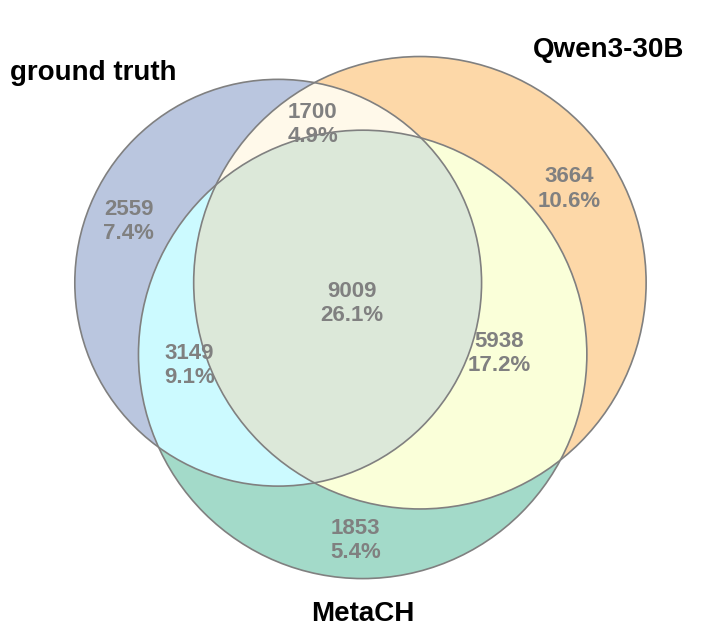

In [4]:
"""Generate Venn diagrams comparing correct predictions across models."""

# Filter to only include rows where all three columns have data
venn_df = merged_predictions.dropna(subset=['ground_truth', 'qwen3_correct', 'MetaCH_correct'])

print(f"Samples for Venn diagram: {len(venn_df)}")
print(f"\nAccuracy by model:")
for model_name in MODEL_NAMES:
    correct_col = f'{model_name}_correct'
    pred_col = f'{model_name}_pred'
    if correct_col in venn_df.columns:
        accuracy = (venn_df[correct_col] != '').sum() / len(venn_df)
        print(f"{model_name}: {accuracy:.2%}")

venn_df = venn_df.rename(columns={'qwen3_correct': 'Qwen3-30B', 'MetaCH_correct': 'MetaCH'})
myVenn(venn_df, 'ground_truth', 'Qwen3-30B', 'MetaCH',
       savepath="ground_truth_qwen3_metach_venn.pdf")

In [5]:
venn_df

,SAMPLE_ID,CANCER_TYPE,ground_truth,gpt-5_pred,gpt-5_prob,o3-mini_pred,o3-mini_prob,gpt-4o_pred,gpt-4o_prob,medgemma_pred,...,gpt-4o_correct,medgemma_correct,Qwen3-30B,claude-sonnet-37_correct,claude-opus-45_correct,deepseek_correct,MetaCH,ground_truth_set,Qwen3-30B_set,MetaCH_set
0,GENIE-MSK-P-0041636-T01-IM6,Endometrial Cancer,TUMOR-SOMATIC,TUMOR-SOMATIC,0.78,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.68,TUMOR-SOMATIC,...,TUMOR-SOMATIC,TUMOR-SOMATIC,TUMOR-SOMATIC,,TUMOR-SOMATIC,TUMOR-SOMATIC,TUMOR-SOMATIC,TUMOR-SOMATICGENIE-MSK-P-0041636-T01-IM6,TUMOR-SOMATICGENIE-MSK-P-0041636-T01-IM6,TUMOR-SOMATICGENIE-MSK-P-0041636-T01-IM6
1,GENIE-MSK-P-0058855-T01-IM7,Melanoma,TUMOR-SOMATIC,TUMOR-SOMATIC,0.86,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.83,TUMOR-SOMATIC,...,TUMOR-SOMATIC,TUMOR-SOMATIC,,TUMOR-SOMATIC,TUMOR-SOMATIC,TUMOR-SOMATIC,TUMOR-SOMATIC,TUMOR-SOMATICGENIE-MSK-P-0058855-T01-IM7,GENIE-MSK-P-0058855-T01-IM7,TUMOR-SOMATICGENIE-MSK-P-0058855-T01-IM7
2,P-0044061-N01-IM6,Breast Cancer,CHIP,CHIP,0.86,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.66,TUMOR-SOMATIC,...,,,,CHIP,,,CHIP,CHIPP-0044061-N01-IM6,P-0044061-N01-IM6,CHIPP-0044061-N01-IM6
3,GENIE-MSK-P-0040623-T01-IM6,Melanoma,TUMOR-SOMATIC,TUMOR-SOMATIC,0.70,TUMOR-SOMATIC,0.92,TUMOR-SOMATIC,0.78,TUMOR-SOMATIC,...,TUMOR-SOMATIC,TUMOR-SOMATIC,TUMOR-SOMATIC,,,TUMOR-SOMATIC,TUMOR-SOMATIC,TUMOR-SOMATICGENIE-MSK-P-0040623-T01-IM6,TUMOR-SOMATICGENIE-MSK-P-0040623-T01-IM6,TUMOR-SOMATICGENIE-MSK-P-0040623-T01-IM6
4,GENIE-MSK-P-0053187-T01-IM6,Renal Cell Carcinoma,TUMOR-SOMATIC,TUMOR-SOMATIC,0.90,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.62,TUMOR-SOMATIC,...,TUMOR-SOMATIC,TUMOR-SOMATIC,,,TUMOR-SOMATIC,,TUMOR-SOMATIC,TUMOR-SOMATICGENIE-MSK-P-0053187-T01-IM6,GENIE-MSK-P-0053187-T01-IM6,TUMOR-SOMATICGENIE-MSK-P-0053187-T01-IM6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34553,GENIE-MSK-P-0043530-T01-IM6,Non-Small Cell Lung Cancer,TUMOR-SOMATIC,TUMOR-SOMATIC,0.80,TUMOR-SOMATIC,0.90,CHIP,0.84,TUMOR-SOMATIC,...,,TUMOR-SOMATIC,,,,TUMOR-SOMATIC,,TUMOR-SOMATICGENIE-MSK-P-0043530-T01-IM6,GENIE-MSK-P-0043530-T01-IM6,GENIE-MSK-P-0043530-T01-IM6
34554,GENIE-MSK-P-0060711-T01-IM7,Pancreatic Cancer,TUMOR-SOMATIC,TUMOR-SOMATIC,0.93,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.76,TUMOR-SOMATIC,...,TUMOR-SOMATIC,TUMOR-SOMATIC,TUMOR-SOMATIC,,TUMOR-SOMATIC,TUMOR-SOMATIC,TUMOR-SOMATIC,TUMOR-SOMATICGENIE-MSK-P-0060711-T01-IM7,TUMOR-SOMATICGENIE-MSK-P-0060711-T01-IM7,TUMOR-SOMATICGENIE-MSK-P-0060711-T01-IM7
34555,GENIE-MSK-P-0037515-T01-IM6,Head and Neck Cancer,TUMOR-SOMATIC,TUMOR-SOMATIC,0.90,TUMOR-SOMATIC,0.95,TUMOR-SOMATIC,0.78,TUMOR-SOMATIC,...,TUMOR-SOMATIC,TUMOR-SOMATIC,,,,,,TUMOR-SOMATICGENIE-MSK-P-0037515-T01-IM6,GENIE-MSK-P-0037515-T01-IM6,GENIE-MSK-P-0037515-T01-IM6
34556,P-0035850-N01-IM6,Glioma,CHIP,CHIP,0.88,CHIP,0.95,CHIP,0.86,CHIP,...,CHIP,CHIP,,,,CHIP,,CHIPP-0035850-N01-IM6,P-0035850-N01-IM6,P-0035850-N01-IM6
